## Ejercicio 1


In [1]:
import numpy as np
import csv

class PerceptronSimpleOO:
    def __init__(self, num_entradas, tasa_aprendizaje, epocas_maximas, tolerancia_error):
        # bias --> w[0]
        self.w = np.random.uniform(-0.5, 0.5, num_entradas)
        self.tasa_aprendizaje = tasa_aprendizaje
        self.epocas_maximas = epocas_maximas
        self.tolerancia_error = tolerancia_error
        
    def funcion_signo(self, z):
        return 1 if z >= 0 else -1
        
    def predecir(self, x):
        z = np.dot(x, self.w)
        return self.funcion_signo(z)
        
    def train(self, X_train, Y_train):
        max_errores_permitidos = len(Y_train) * self.tolerancia_error
        
        for epoca in range(self.epocas_maximas):
            # ajuste de pesos
            for x, yd in zip(X_train, Y_train):
                y = self.predecir(x)
                if y != yd:
                    error = yd - y
                    self.w += (self.tasa_aprendizaje/2) * error * x
            
            fallos = 0
            for x, yd in zip(X_train, Y_train):
                if self.predecir(x) != yd:
                    fallos += 1

            # criterio de corte
            if fallos < max_errores_permitidos:
                print(f"Convergencia en la epoca {epoca + 1} (Fallos: {fallos})")
                return self.w
                
        print(f"Fin del entrenamiento por limite de epocas. Fallos finales: {fallos}")
        return self.w

    def test(self, X_test, Y_test):
        aciertos = 0
        total = len(Y_test)
        
        for x, yd in zip(X_test, Y_test):
            if self.predecir(x) == yd:
                aciertos += 1
                
        precision = (aciertos / total) * 100
        print(f"Resultado Test: Se calcularon correctamente {aciertos} de {total} ({precision:.1f}%)")
        return precision


def cargar_datos(ruta_archivo):
    datos_x = []
    yd = []
    with open(ruta_archivo, 'r') as archivo:
        archivo_csv = csv.reader(archivo)
        for i in archivo_csv:
            datos_x.append([-1.0, float(i[0]), float(i[1])])
            yd.append(int(i[2]))
    return np.array(datos_x), np.array(yd)


if __name__ == "__main__":
    X_trn, Y_trn = cargar_datos('datos/OR_trn.csv')

    num_entradas = X_trn.shape[1]
    perc_simple = PerceptronSimpleOO(num_entradas=num_entradas, tasa_aprendizaje=0.01, epocas_maximas=10, tolerancia_error=0.05)
    
    perc_simple.train(X_trn, Y_trn)
    
    print("")
    X_tst, Y_tst = cargar_datos('datos/OR_tst.csv')
    perc_simple.test(X_tst, Y_tst)

Convergencia en la epoca 1 (Fallos: 0)

Resultado Test: Se calcularon correctamente 200 de 200 (100.0%)


## Ejercicio 2

Caso OR: 


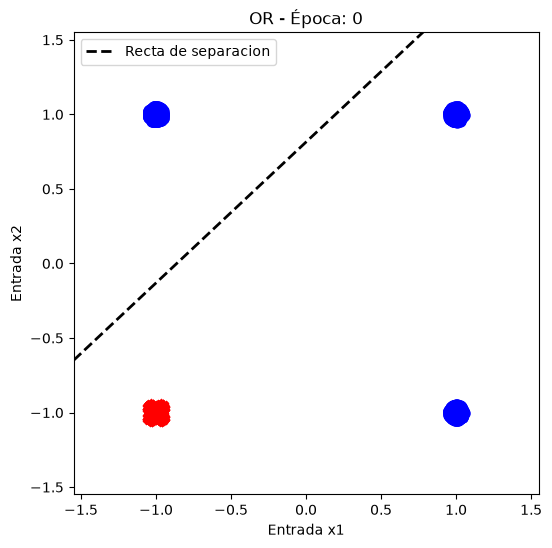

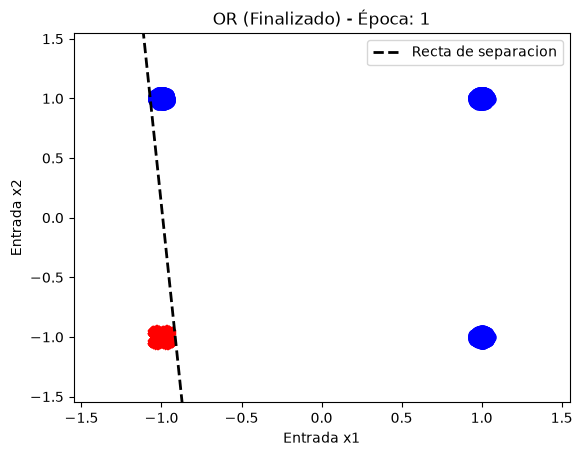

[OR] - Convergencia en epoca 1
[OR] - Entrenamiento terminado. Fallos: 0
 
Caso XOR: 


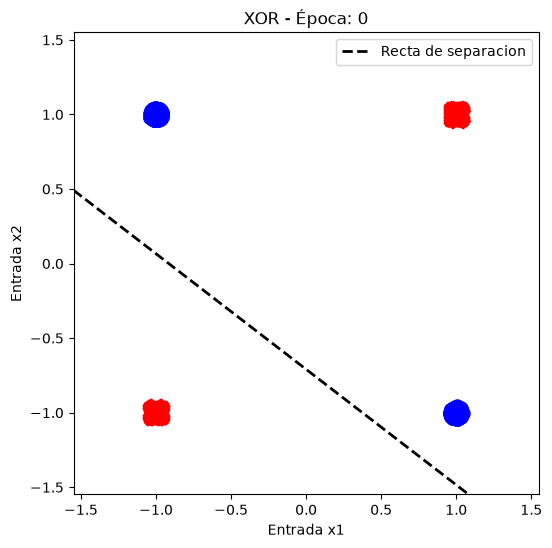

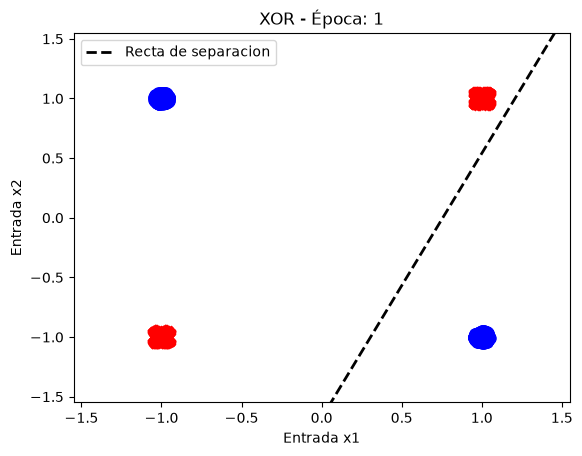

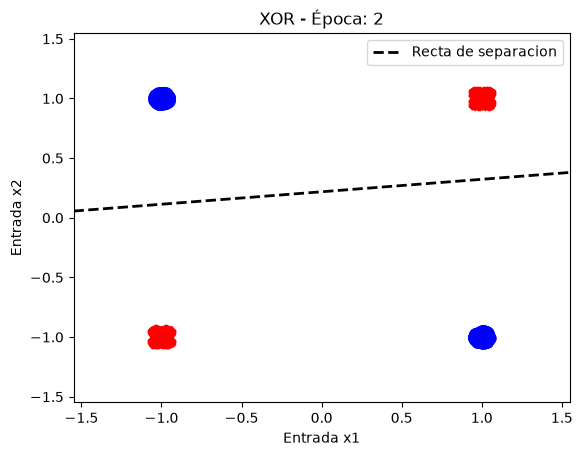

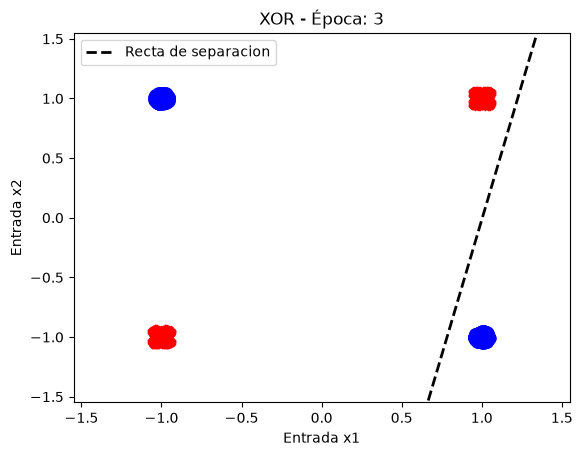

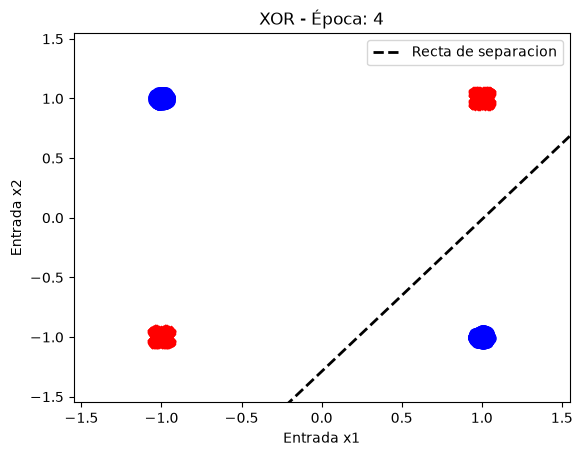

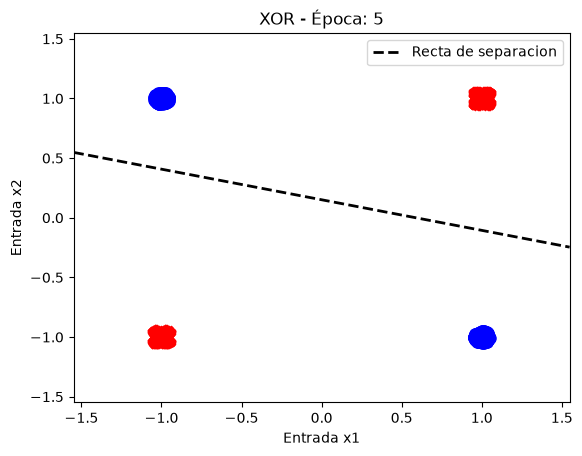

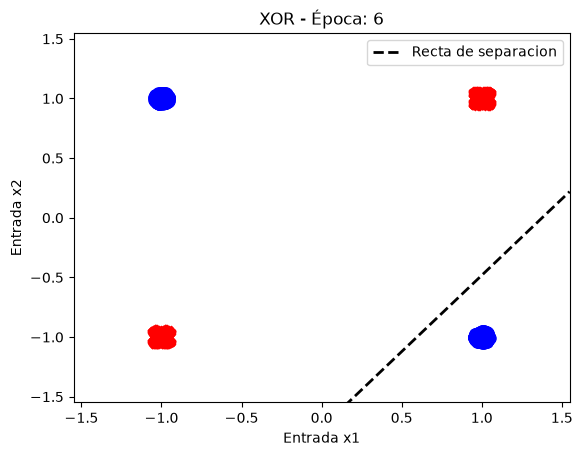

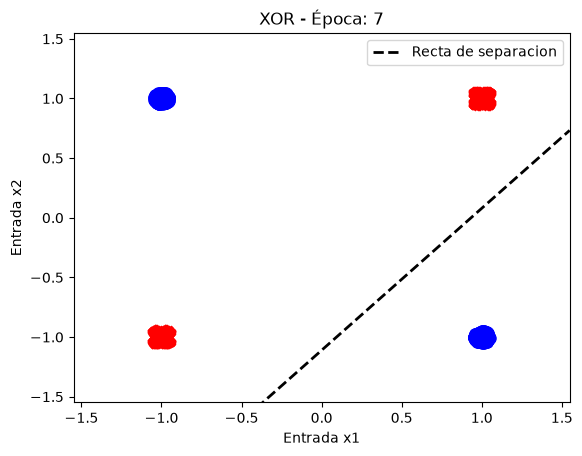

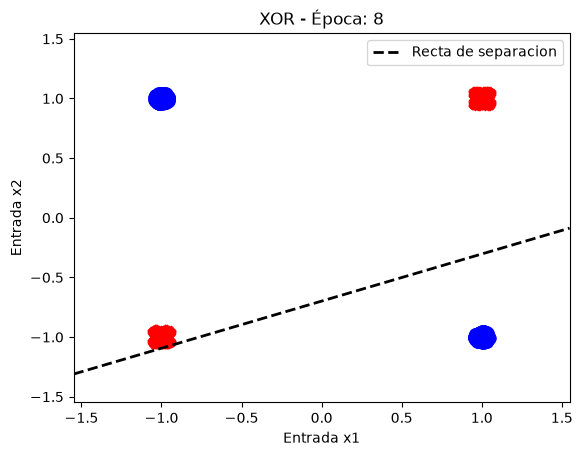

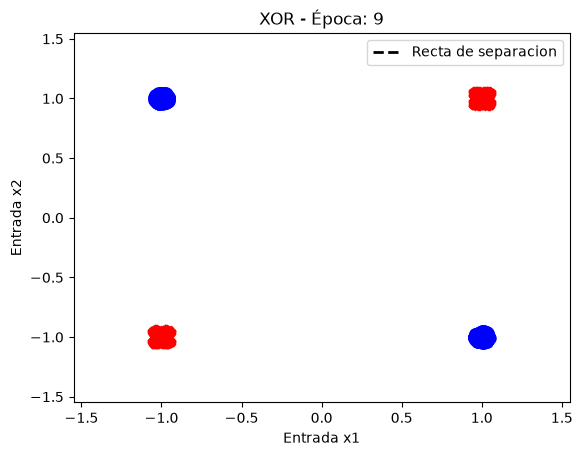

[XOR] - Entrenamiento terminado. Fallos: 1007


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import csv

class PerceptronGrafico:
    def __init__(self, num_entradas, tasa_aprendizaje, epocas_maximas, tolerancia_error=0):
        self.w = np.random.uniform(-0.5, 0.5, num_entradas)
        self.tasa_aprendizaje = tasa_aprendizaje
        self.epocas_maximas = epocas_maximas
        self.tolerancia_error = tolerancia_error
        
    def funcion_signo(self, z):
        return 1 if z >= 0 else -1
        
    def predecir(self, x):
        z = np.dot(x, self.w)
        return self.funcion_signo(z)
        
    def graficar_estado(self, X, Y, epoca, titulo):
        plt.clf()
        plt.title(f"{titulo} - Época: {epoca}")
        plt.xlabel("Entrada x1")
        plt.ylabel("Entrada x2")
        
        for i in range(len(X)):
            if Y[i] == 1:
                # indices 1 y 2 porque el indices 0 es el bias (-1)
                plt.plot(X[i][1], X[i][2], 'bo', markersize=8) 
            else:
                plt.plot(X[i][1], X[i][2], 'rx', markersize=8, markeredgewidth=2)

        # recta de separacion
        if self.w[2] != 0:
            x1_min, x1_max = np.min(X[:, 1]) - 0.5, np.max(X[:, 1]) + 0.5
            x1_vals = np.array([x1_min, x1_max])
            
            # x2 = (w0 - w1*x1) / w2
            x2_vals = (self.w[0] - self.w[1] * x1_vals) / self.w[2]
            plt.plot(x1_vals, x2_vals, 'k--', linewidth=2, label="Recta de separacion")

        # limites de la ventana
        plt.xlim(np.min(X[:, 1]) - 0.5, np.max(X[:, 1]) + 0.5)
        plt.ylim(np.min(X[:, 2]) - 0.5, np.max(X[:, 2]) + 0.5)
        plt.legend(loc="best")
        plt.pause(0.5)

    def train(self, X_train, Y_train, titulo_grafico):
        max_errores_permitidos = len(Y_train) * self.tolerancia_error
        
        plt.ion()
        plt.figure(figsize=(6, 6))

        for epoca in range(self.epocas_maximas):
            # grafico antes de los ajustes de la epoca
            self.graficar_estado(X_train, Y_train, epoca, titulo_grafico)
            
            for x, yd in zip(X_train, Y_train):
                y = self.predecir(x)
                if y != yd:
                    error = yd - y
                    self.w += (self.tasa_aprendizaje/2) * error * x
            
            fallos = 0
            for x, yd in zip(X_train, Y_train):
                if self.predecir(x) != yd:
                    fallos += 1

            # criterio de corte
            if fallos <= max_errores_permitidos:
                self.graficar_estado(X_train, Y_train, epoca + 1, titulo_grafico + " (Finalizado)")
                print(f"[{titulo_grafico}] - Convergencia en epoca {epoca + 1}")
                break
                
        print(f"[{titulo_grafico}] - Entrenamiento terminado. Fallos: {fallos}")
        plt.ioff()
        plt.show() 


def cargar_datos(ruta_archivo):
    datos_x = []
    yd = []
    with open(ruta_archivo, 'r') as archivo:
        archivo_csv = csv.reader(archivo)
        for i in archivo_csv:
            datos_x.append([-1.0, float(i[0]), float(i[1])])
            yd.append(int(i[2]))
    return np.array(datos_x), np.array(yd)


if __name__ == "__main__":
    print("Caso OR: ")
    X_or, Y_or = cargar_datos("datos/OR_trn.csv")
    entradas = X_or.shape[1]
    red_or = PerceptronGrafico(num_entradas=entradas, tasa_aprendizaje=0.01, epocas_maximas=10)
    red_or.train(X_or, Y_or, titulo_grafico="OR")

    print(" ")
    print("Caso XOR: ")
    X_xor, Y_xor = cargar_datos("datos/XOR_trn.csv")
    entradas = X_xor.shape[1]
    red_xor = PerceptronGrafico(num_entradas=entradas, tasa_aprendizaje=0.01, epocas_maximas=10)
    red_xor.train(X_xor, Y_xor, titulo_grafico="XOR")


## Ejercicio 3

Caso OR_50: 


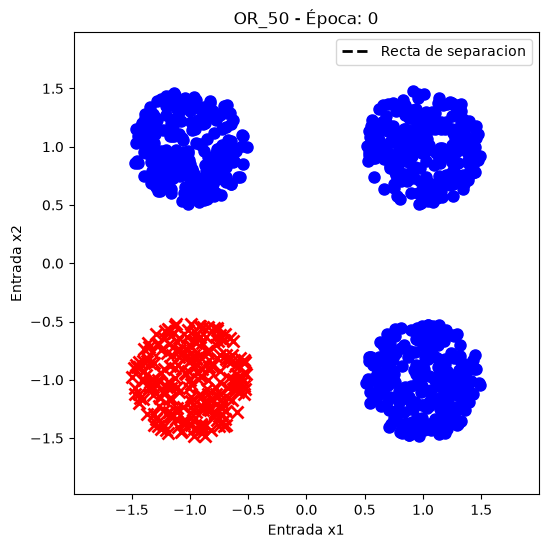

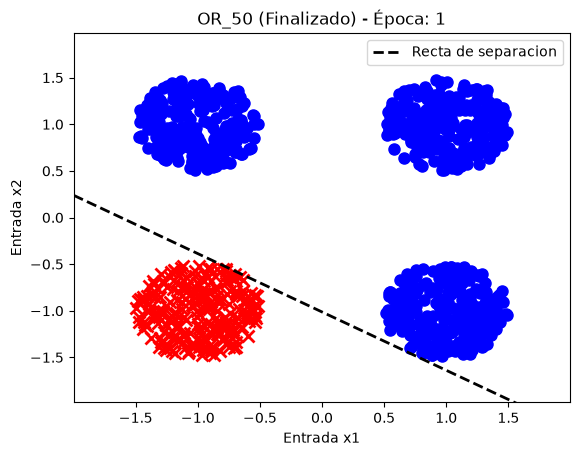

[OR_50] - Convergencia en epoca 1
[OR_50] - Entrenamiento terminado. Fallos: 0

Resultado Test: Se calcularon correctamente 200 de 200 (100.0%)

Caso OR_90: 


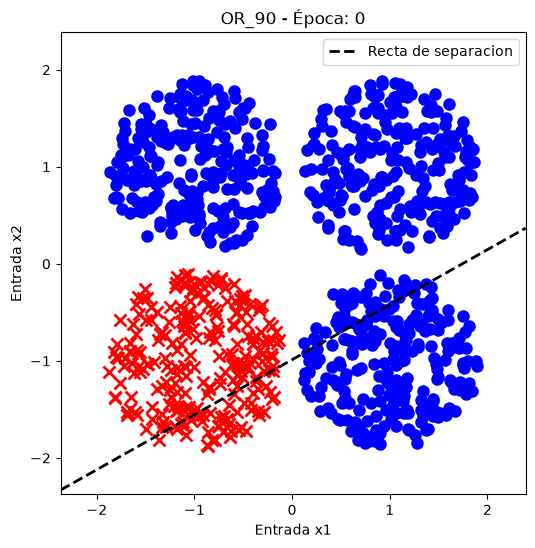

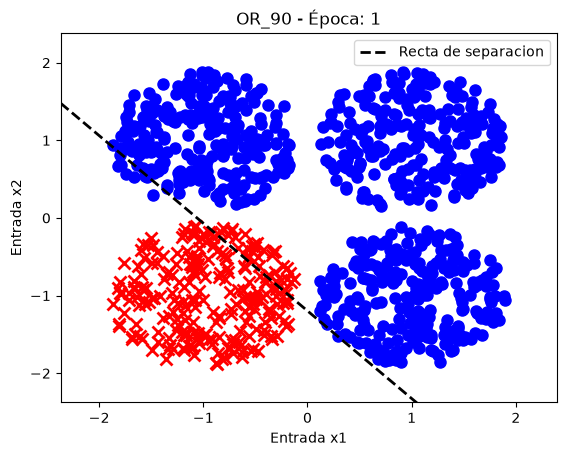

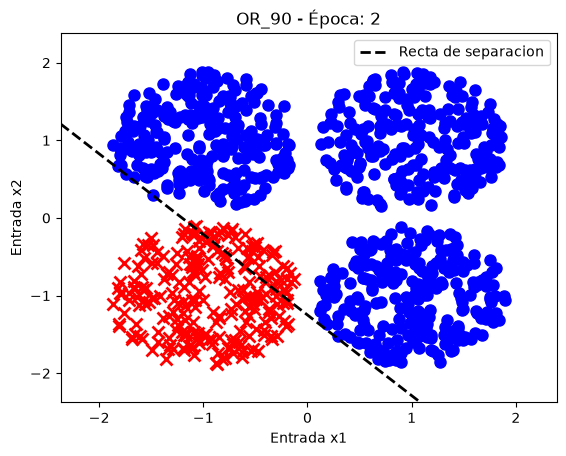

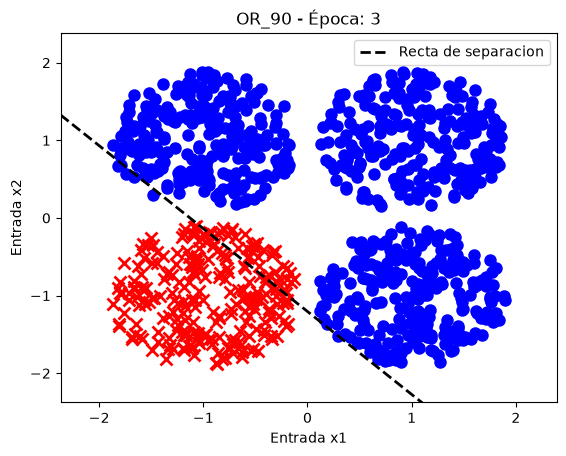

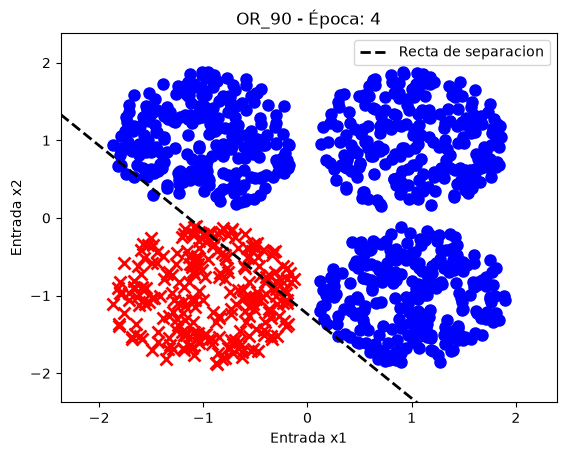

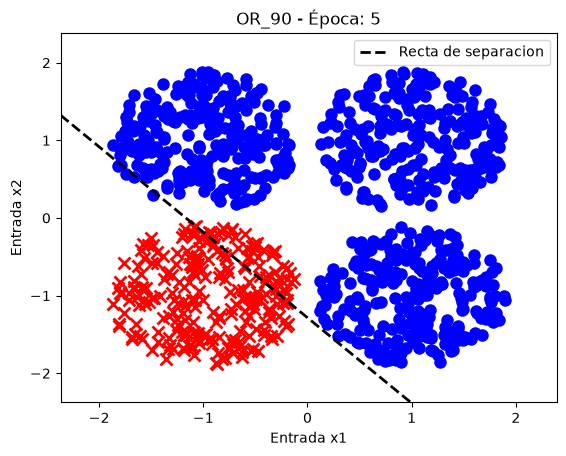

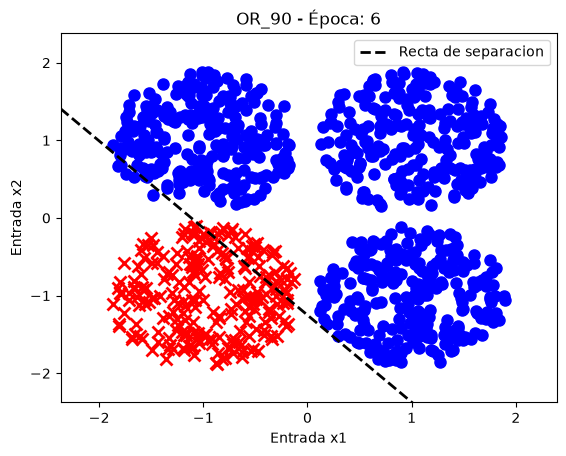

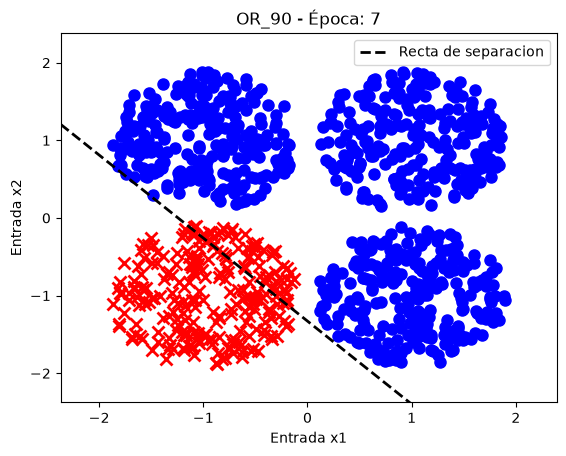

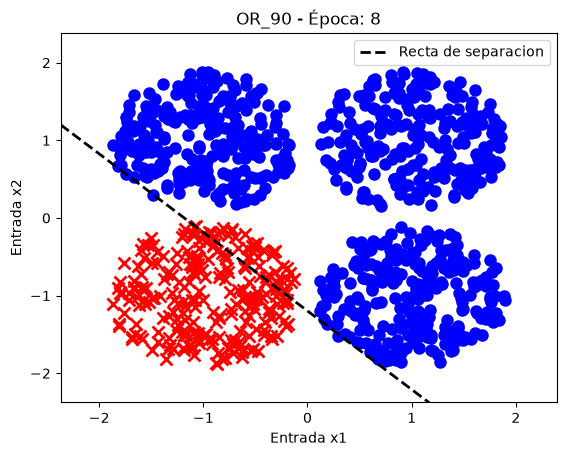

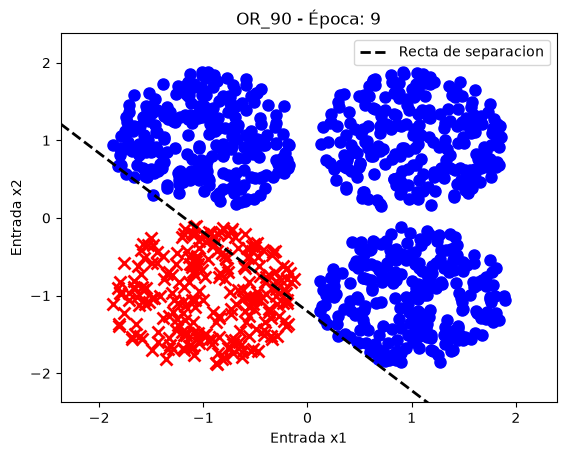

[OR_90] - Entrenamiento terminado. Fallos: 60

Resultado Test: Se calcularon correctamente 188 de 200 (94.0%)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import csv

class PerceptronGrafico:
    def __init__(self, num_entradas, tasa_aprendizaje, epocas_maximas, tolerancia_error=0):
        self.w = np.random.uniform(-0.5, 0.5, num_entradas)
        self.tasa_aprendizaje = tasa_aprendizaje
        self.epocas_maximas = epocas_maximas
        self.tolerancia_error = tolerancia_error
        
    def funcion_signo(self, z):
        return 1 if z >= 0 else -1
        
    def predecir(self, x):
        z = np.dot(x, self.w)
        return self.funcion_signo(z)
        
    def graficar_estado(self, X, Y, epoca, titulo):
        plt.clf()
        plt.title(f"{titulo} - Época: {epoca}")
        plt.xlabel("Entrada x1")
        plt.ylabel("Entrada x2")
        
        for i in range(len(X)):
            if Y[i] == 1:
                # indices 1 y 2 porque el indices 0 es el bias (-1)
                plt.plot(X[i][1], X[i][2], 'bo', markersize=8) 
            else:
                plt.plot(X[i][1], X[i][2], 'rx', markersize=8, markeredgewidth=2)

        # recta de separacion
        if self.w[2] != 0:
            x1_min, x1_max = np.min(X[:, 1]) - 0.5, np.max(X[:, 1]) + 0.5
            x1_vals = np.array([x1_min, x1_max])
            
            # x2 = (w0 - w1*x1) / w2
            x2_vals = (self.w[0] - self.w[1] * x1_vals) / self.w[2]
            plt.plot(x1_vals, x2_vals, 'k--', linewidth=2, label="Recta de separacion")

        # limites de la ventana
        plt.xlim(np.min(X[:, 1]) - 0.5, np.max(X[:, 1]) + 0.5)
        plt.ylim(np.min(X[:, 2]) - 0.5, np.max(X[:, 2]) + 0.5)
        plt.legend(loc="best")
        plt.pause(0.5)

    def train(self, X_train, Y_train, titulo_grafico):
        max_errores_permitidos = len(Y_train) * self.tolerancia_error
        
        plt.ion()
        plt.figure(figsize=(6, 6))

        for epoca in range(self.epocas_maximas):
            # grafico antes de los ajustes de la epoca
            self.graficar_estado(X_train, Y_train, epoca, titulo_grafico)
            
            for x, yd in zip(X_train, Y_train):
                y = self.predecir(x)
                if y != yd:
                    error = yd - y
                    self.w += (self.tasa_aprendizaje/2) * error * x
            
            # criterio de corte
            fallos = 0
            for x, yd in zip(X_train, Y_train):
                if self.predecir(x) != yd:
                    fallos += 1
                    
            if fallos <= max_errores_permitidos:
                self.graficar_estado(X_train, Y_train, epoca + 1, titulo_grafico + " (Finalizado)")
                print(f"[{titulo_grafico}] - Convergencia en epoca {epoca + 1}")
                break
                
        print(f"[{titulo_grafico}] - Entrenamiento terminado. Fallos: {fallos}")
        plt.ioff()
        plt.show()

    def test(self, X_test, Y_test):
        aciertos = 0
        total = len(Y_test)
        
        for x, yd in zip(X_test, Y_test):
            if self.predecir(x) == yd:
                aciertos += 1
                
        precision = (aciertos / total) * 100
        print(f"Resultado Test: Se calcularon correctamente {aciertos} de {total} ({precision:.1f}%)")
        return precision


def cargar_datos(ruta_archivo):
    datos_x = []
    yd = []
    with open(ruta_archivo, 'r') as archivo:
        archivo_csv = csv.reader(archivo)
        for i in archivo_csv:
            datos_x.append([-1.0, float(i[0]), float(i[1])])
            yd.append(int(i[2]))
    return np.array(datos_x), np.array(yd)


if __name__ == "__main__":
    X_trn_50, Y_trn_50 = cargar_datos("datos/OR_50_trn.csv")
    X_tst_50, Y_tst_50 = cargar_datos("datos/OR_50_tst.csv")
    red_50 = PerceptronGrafico(num_entradas=3, tasa_aprendizaje=0.01, epocas_maximas=10)
    
    print("Caso OR_50: ")
    red_50.train(X_trn_50, Y_trn_50, titulo_grafico="OR_50")
    print("")
    red_50.test(X_tst_50, Y_tst_50)

    print("")
    X_trn_90, Y_trn_90 = cargar_datos("datos/OR_90_trn.csv")
    X_tst_90, Y_tst_90 = cargar_datos("datos/OR_90_tst.csv")
    red_90 = PerceptronGrafico(num_entradas=3, tasa_aprendizaje=0.01, epocas_maximas=10)
    
    print("Caso OR_90: ")
    red_90.train(X_trn_90, Y_trn_90, titulo_grafico="OR_90")
    
    print("")
    red_90.test(X_tst_90, Y_tst_90)
